In [18]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
import sqlite3

In [4]:
new_df = pd.read_csv('IMDB Dataset.csv')
new_df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
new_df.shape


(50000, 2)

In [13]:
new_df.sentiment.unique()

array(['positive', 'negative'], dtype=object)

In [14]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


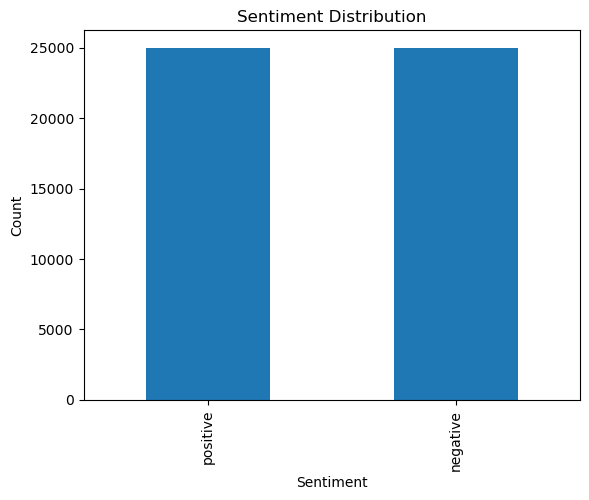

In [17]:

print(new_df['sentiment'].value_counts())

new_df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [19]:
conn = sqlite3.connect('imdb_reviews.db')

In [20]:
new_df.to_sql('reviews', conn, if_exists='replace', index=False)
print("Data loaded into SQLite successfully")

Data loaded into SQLite successfully


In [21]:
query = """
    SELECT sentiment, COUNT(*) as count 
    FROM reviews 
    GROUP BY sentiment
"""

In [22]:
result = pd.read_sql_query(query, conn)
print(result)

  sentiment  count
0  negative  25000
1  positive  25000


In [23]:
query = "SELECT * FROM reviews LIMIT 10"
result = pd.read_sql_query(query, conn)
print(result)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
5  Probably my all-time favorite movie, a story o...  positive
6  I sure would like to see a resurrection of a u...  positive
7  This show was an amazing, fresh & innovative i...  negative
8  Encouraged by the positive comments about this...  negative
9  If you like original gut wrenching laughter yo...  positive


In [24]:
query = """
    SELECT sentiment, COUNT(*) as total
    FROM reviews
    GROUP BY sentiment
"""
result = pd.read_sql_query(query, conn)
print(result)

  sentiment  total
0  negative  25000
1  positive  25000


In [36]:
query = """
    SELECT COUNT(*) as total
    FROM reviews
    WHERE sentiment = 'positive' 
    AND LENGTH(review) > 10000
    
"""
result = pd.read_sql_query(query, conn)
print(result)


   total
0      6


In [37]:
query = """
    SELECT review, LENGTH(review) as review_length, sentiment
    FROM reviews
    ORDER BY review_length DESC
    LIMIT 5
"""
result = pd.read_sql_query(query, conn)
print(result)

                                              review  review_length sentiment
0  Match 1: Tag Team Table Match Bubba Ray and Sp...          13704  positive
1  There's a sign on The Lost Highway that says:<...          12988  positive
2  (Some spoilers included:)<br /><br />Although,...          12930  positive
3  Back in the mid/late 80s, an OAV anime by titl...          12129  positive
4  **Attention Spoilers**<br /><br />First of all...          10363  positive


In [38]:
query = """
    SELECT sentiment, AVG(LENGTH(review)) as avg_length
    FROM reviews
    GROUP BY sentiment
"""
result = pd.read_sql_query(query, conn)
print(result)

  sentiment  avg_length
0  negative  1294.06436
1  positive  1324.79768


## SQL EDA Finding:
Positive reviews have longer average length than negative reviews.
This suggests sentiment may correlate with review verbosity.

In [39]:
query = """
    SELECT sentiment,
           AVG(LENGTH(review)) as avg_length,
           MAX(LENGTH(review)) as max_length,
           MIN(LENGTH(review)) as min_length
    FROM reviews
    GROUP BY sentiment
"""
result = pd.read_sql_query(query, conn)
print(result)

  sentiment  avg_length  max_length  min_length
0  negative  1294.06436        8969          32
1  positive  1324.79768       13704          65


## SQL EDA Findings:
1. Positive reviews slightly longer on average (1324 vs 1294 chars)
2. Difference is minimal — text content matters more than length
3. Shortest negative review (32 chars) confirms quick venting pattern

### Text Preprocessing

In [40]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\umar
[nltk_data]     ayaan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\umar
[nltk_data]     ayaan\AppData\Roaming\nltk_data...


True

In [41]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [42]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

In [50]:
new_df['cleaned'] = new_df['review'].apply(clean_text)

In [46]:
new_df['cleaned']

0        one reviewer mentioned watching oz episode you...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movie high art fan expec...
Name: cleaned, Length: 50000, dtype: object

In [51]:
print(new_df[['review', 'cleaned']].head(3))

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   

                                             cleaned  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
